# **German Credit Risk**

## **Obtener la data**

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 
  
# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables) 


{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

## **Variables**

In [3]:
default_of_credit_card_clients.variables.description.to_list()

[nan,
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [4]:
columns_names = [ 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',]

In [5]:
X.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23'],
      dtype='str')

Asignamos el column names a X

In [6]:
X.columns = columns_names

## **Feature Engineer**

In [7]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,...,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


### **Distribucion de target: y**

array([[<Axes: title={'center': 'Y'}>]], dtype=object)

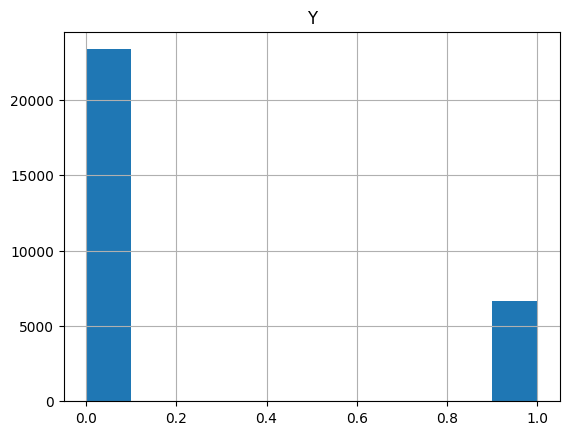

In [8]:
y.hist()

In [9]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,...,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


## **EDA** 

Analisis de todas las variables, encontrar relaciones importantes, y crear variables

In [10]:
X.LIMIT_BAL.describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

<Axes: >

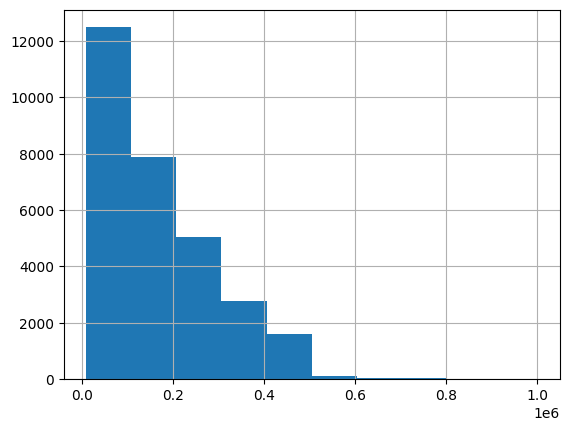

In [11]:
X.LIMIT_BAL.hist()

In [12]:
X["target"] = y

<Axes: >

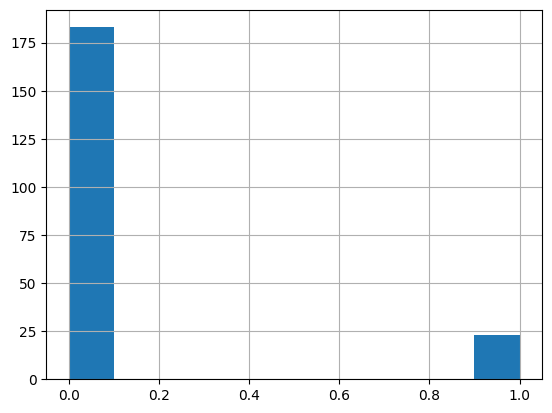

In [13]:
X[X["LIMIT_BAL"]>500000].target.hist()

### **Crear variables**

In [14]:
X.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target'],
      dtype='str')

In [15]:
import numpy as np

cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

X["flag"] = np.where(X[cols].ne(-1, 0).any(axis=1), 1, 0)

In [16]:
cols_bills = ['BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

X["AVG_BILL"] = X[cols_bills].sum(axis=1)/6

In [17]:
X["RATIO_PAY_1"] = X["PAY_AMT1"]/X["BILL_AMT1"]
X["RATIO_PAY_2"] = X["PAY_AMT2"]/X["BILL_AMT2"]
X["RATIO_PAY_3"] = X["PAY_AMT3"]/X["BILL_AMT3"]

In [18]:
X.replace([np.inf, -np.inf], 0, inplace=True)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,1,1,1284.000000,0.000000,0.222115,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,0,2000,1,1,2846.166667,0.000000,0.579710,0.372856
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,1000,5000,0,1,16942.166667,0.051917,0.106937,0.073752
3,50000,2,2,1,37,0,0,0,0,0,...,1200,1100,1069,1000,0,1,38555.666667,0.042562,0.041859,0.024345
4,50000,1,2,1,57,-1,0,-1,0,0,...,10000,9000,689,679,0,1,18223.166667,0.232099,6.469312,0.279057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,5003,3047,5000,1000,0,1,120891.500000,0.044986,0.103726,0.024011
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8998,129,0,0,0,1,3530.333333,1.091503,1.928884,2.569389
29997,30000,1,2,2,37,4,3,2,-1,0,...,22000,4200,2000,3100,1,1,11749.333333,0.000000,0.000000,7.976795
29998,80000,1,3,1,41,1,-1,0,0,0,...,1178,1926,52964,1804,1,1,44435.166667,-52.218845,0.043494,0.015438


In [19]:
X["BILL_AMT1"]

0          3913
1          2682
2         29239
3         46990
4          8617
          ...  
29995    188948
29996      1683
29997      3565
29998     -1645
29999     47929
Name: BILL_AMT1, Length: 30000, dtype: int64

## **Feature Engineer**

In [20]:
len(X)

30000

In [21]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LIMIT_BAL    30000 non-null  int64  
 1   SEX          30000 non-null  int64  
 2   EDUCATION    30000 non-null  int64  
 3   MARRIAGE     30000 non-null  int64  
 4   AGE          30000 non-null  int64  
 5   PAY_0        30000 non-null  int64  
 6   PAY_2        30000 non-null  int64  
 7   PAY_3        30000 non-null  int64  
 8   PAY_4        30000 non-null  int64  
 9   PAY_5        30000 non-null  int64  
 10  PAY_6        30000 non-null  int64  
 11  BILL_AMT1    30000 non-null  int64  
 12  BILL_AMT2    30000 non-null  int64  
 13  BILL_AMT3    30000 non-null  int64  
 14  BILL_AMT4    30000 non-null  int64  
 15  BILL_AMT5    30000 non-null  int64  
 16  BILL_AMT6    30000 non-null  int64  
 17  PAY_AMT1     30000 non-null  int64  
 18  PAY_AMT2     30000 non-null  int64  
 19  PAY_AMT3     30

In [22]:
X.isna().sum()

LIMIT_BAL         0
SEX               0
EDUCATION         0
MARRIAGE          0
AGE               0
PAY_0             0
PAY_2             0
PAY_3             0
PAY_4             0
PAY_5             0
PAY_6             0
BILL_AMT1         0
BILL_AMT2         0
BILL_AMT3         0
BILL_AMT4         0
BILL_AMT5         0
BILL_AMT6         0
PAY_AMT1          0
PAY_AMT2          0
PAY_AMT3          0
PAY_AMT4          0
PAY_AMT5          0
PAY_AMT6          0
target            0
flag              0
AVG_BILL          0
RATIO_PAY_1    1468
RATIO_PAY_2    1867
RATIO_PAY_3    2246
dtype: int64

## 1. Missing data fill

In [23]:
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator

In [24]:
imputer_0 = SimpleImputer(strategy='constant', fill_value=0)

In [25]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,1,1,1284.000000,0.000000,0.222115,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,0,2000,1,1,2846.166667,0.000000,0.579710,0.372856
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,1000,5000,0,1,16942.166667,0.051917,0.106937,0.073752
3,50000,2,2,1,37,0,0,0,0,0,...,1200,1100,1069,1000,0,1,38555.666667,0.042562,0.041859,0.024345
4,50000,1,2,1,57,-1,0,-1,0,0,...,10000,9000,689,679,0,1,18223.166667,0.232099,6.469312,0.279057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,5003,3047,5000,1000,0,1,120891.500000,0.044986,0.103726,0.024011
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8998,129,0,0,0,1,3530.333333,1.091503,1.928884,2.569389
29997,30000,1,2,2,37,4,3,2,-1,0,...,22000,4200,2000,3100,1,1,11749.333333,0.000000,0.000000,7.976795
29998,80000,1,3,1,41,1,-1,0,0,0,...,1178,1926,52964,1804,1,1,44435.166667,-52.218845,0.043494,0.015438


In [26]:
X_imputed = imputer_0.fit_transform(X)
X_imputed

array([[ 2.00000000e+04,  2.00000000e+00,  2.00000000e+00, ...,
         0.00000000e+00,  2.22114765e-01,  0.00000000e+00],
       [ 1.20000000e+05,  2.00000000e+00,  2.00000000e+00, ...,
         0.00000000e+00,  5.79710145e-01,  3.72856078e-01],
       [ 9.00000000e+04,  2.00000000e+00,  2.00000000e+00, ...,
         5.19169602e-02,  1.06936622e-01,  7.37517516e-02],
       ...,
       [ 3.00000000e+04,  1.00000000e+00,  2.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  7.97679478e+00],
       [ 8.00000000e+04,  1.00000000e+00,  3.00000000e+00, ...,
        -5.22188450e+01,  4.34937930e-02,  1.54382470e-02],
       [ 5.00000000e+04,  1.00000000e+00,  2.00000000e+00, ...,
         4.33557971e-02,  3.68060526e-02,  2.87356322e-02]],
      shape=(30000, 29))

## One-hot or codification strings

In [27]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
import pandas as pd

nominal_cols = ["EDUCATION"]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop = "first")
X_sex = X[nominal_cols]
sex_encoded = ohe.fit_transform(X_sex)

In [28]:
sex_encoded

array([[0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       ...,
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.]], shape=(30000, 6))

In [29]:
ohe.get_feature_names_out(nominal_cols)

array(['EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4',
       'EDUCATION_5', 'EDUCATION_6'], dtype=object)

In [30]:
sex_df = pd.DataFrame(sex_encoded, columns=ohe.get_feature_names_out(nominal_cols))
sex_df

,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6
0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
29995,0.0,0.0,1.0,0.0,0.0,0.0
29996,0.0,0.0,1.0,0.0,0.0,0.0
29997,0.0,1.0,0.0,0.0,0.0,0.0
29998,0.0,0.0,1.0,0.0,0.0,0.0


In [31]:
sex_df = pd.DataFrame(sex_encoded, columns=ohe.get_feature_names_out(nominal_cols))
pd.concat([X, sex_df], axis=1)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,1284.000000,0.000000,0.222115,0.000000,0.0,1.0,0.0,0.0,0.0,0.0
1,120000,2,2,2,26,-1,2,0,0,0,...,2846.166667,0.000000,0.579710,0.372856,0.0,1.0,0.0,0.0,0.0,0.0
2,90000,2,2,2,34,0,0,0,0,0,...,16942.166667,0.051917,0.106937,0.073752,0.0,1.0,0.0,0.0,0.0,0.0
3,50000,2,2,1,37,0,0,0,0,0,...,38555.666667,0.042562,0.041859,0.024345,0.0,1.0,0.0,0.0,0.0,0.0
4,50000,1,2,1,57,-1,0,-1,0,0,...,18223.166667,0.232099,6.469312,0.279057,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,120891.500000,0.044986,0.103726,0.024011,0.0,0.0,1.0,0.0,0.0,0.0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3530.333333,1.091503,1.928884,2.569389,0.0,0.0,1.0,0.0,0.0,0.0
29997,30000,1,2,2,37,4,3,2,-1,0,...,11749.333333,0.000000,0.000000,7.976795,0.0,1.0,0.0,0.0,0.0,0.0
29998,80000,1,3,1,41,1,-1,0,0,0,...,44435.166667,-52.218845,0.043494,0.015438,0.0,0.0,1.0,0.0,0.0,0.0


In [32]:
## Lo de arriba es explicativo, si tengo todo numerico no deberia hacer one-hot
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,1,1,1284.000000,0.000000,0.222115,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,0,2000,1,1,2846.166667,0.000000,0.579710,0.372856
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,1000,5000,0,1,16942.166667,0.051917,0.106937,0.073752
3,50000,2,2,1,37,0,0,0,0,0,...,1200,1100,1069,1000,0,1,38555.666667,0.042562,0.041859,0.024345
4,50000,1,2,1,57,-1,0,-1,0,0,...,10000,9000,689,679,0,1,18223.166667,0.232099,6.469312,0.279057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,5003,3047,5000,1000,0,1,120891.500000,0.044986,0.103726,0.024011
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8998,129,0,0,0,1,3530.333333,1.091503,1.928884,2.569389
29997,30000,1,2,2,37,4,3,2,-1,0,...,22000,4200,2000,3100,1,1,11749.333333,0.000000,0.000000,7.976795
29998,80000,1,3,1,41,1,-1,0,0,0,...,1178,1926,52964,1804,1,1,44435.166667,-52.218845,0.043494,0.015438


## Escalamiento

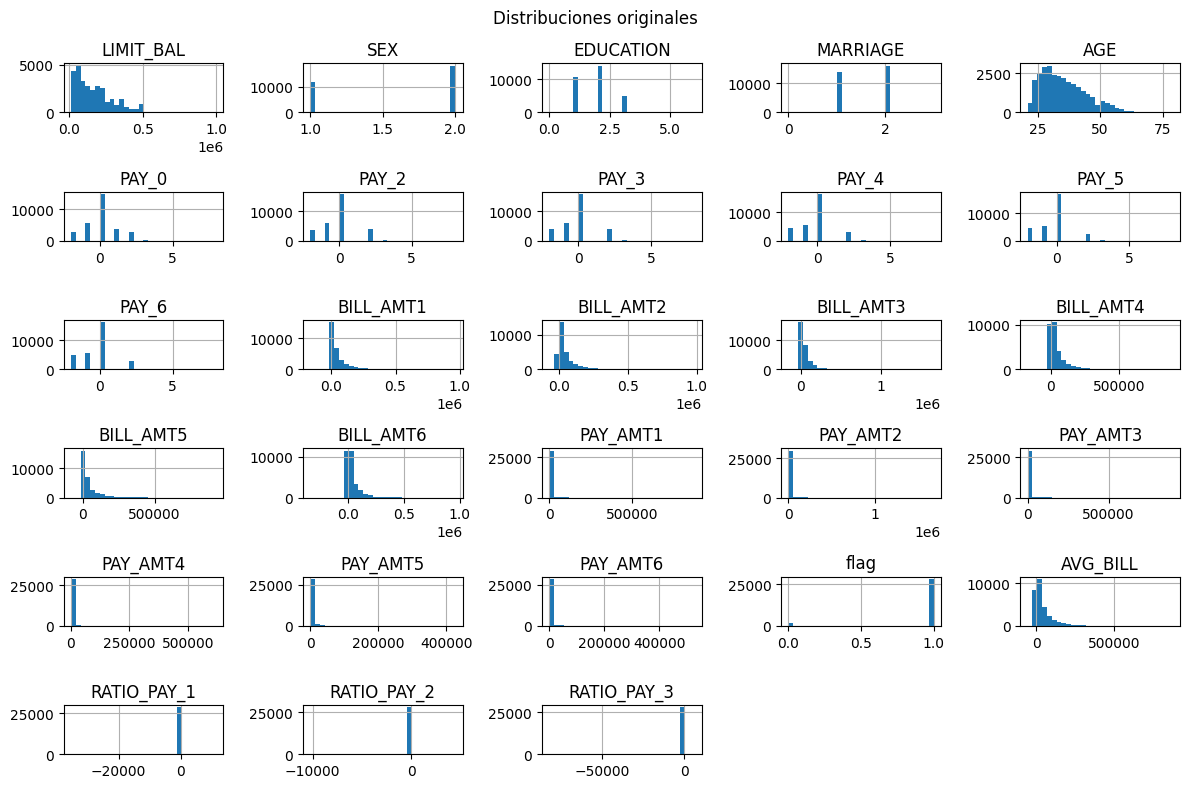

In [33]:
import matplotlib.pyplot as plt

X.drop(columns='target').hist(figsize=(12, 8), bins=30)
plt.suptitle('Distribuciones originales')
plt.tight_layout()
plt.show()

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit_transform(X)

array([[-1.13672015,  0.81016074,  0.18582826, ...,  0.00988139,
         0.01883207,  0.01071792],
       [-0.3659805 ,  0.81016074,  0.18582826, ...,  0.00988139,
         0.02214697,  0.01131364],
       [-0.59720239,  0.81016074,  0.18582826, ...,  0.01010046,
         0.01776437,  0.01083576],
       ...,
       [-1.05964618, -1.23432296,  0.18582826, ...,  0.00988139,
         0.01677307,  0.02346247],
       [-0.67427636, -1.23432296,  1.45111372, ..., -0.21046544,
         0.01717625,  0.01074259],
       [-0.90549825, -1.23432296,  0.18582826, ...,  0.01006433,
         0.01711426,  0.01076383]], shape=(30000, 29))

In [35]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,1,1,1284.000000,0.000000,0.222115,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,0,2000,1,1,2846.166667,0.000000,0.579710,0.372856
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,1000,5000,0,1,16942.166667,0.051917,0.106937,0.073752
3,50000,2,2,1,37,0,0,0,0,0,...,1200,1100,1069,1000,0,1,38555.666667,0.042562,0.041859,0.024345
4,50000,1,2,1,57,-1,0,-1,0,0,...,10000,9000,689,679,0,1,18223.166667,0.232099,6.469312,0.279057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,5003,3047,5000,1000,0,1,120891.500000,0.044986,0.103726,0.024011
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8998,129,0,0,0,1,3530.333333,1.091503,1.928884,2.569389
29997,30000,1,2,2,37,4,3,2,-1,0,...,22000,4200,2000,3100,1,1,11749.333333,0.000000,0.000000,7.976795
29998,80000,1,3,1,41,1,-1,0,0,0,...,1178,1926,52964,1804,1,1,44435.166667,-52.218845,0.043494,0.015438


## Implementacion punta a punta

In [36]:
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

numeric_simple = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),#, fill_value = 0)),
    ('scaler', StandardScaler())
])

categorical_simple = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])


In [37]:
X.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target',
       'flag', 'AVG_BILL', 'RATIO_PAY_1', 'RATIO_PAY_2', 'RATIO_PAY_3'],
      dtype='str')

In [38]:
num_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'flag', 'AVG_BILL', 'RATIO_PAY_1', 'RATIO_PAY_2', 'RATIO_PAY_3']
cat_cols = ["EDUCATION"]

In [39]:

preprocess_simple = ColumnTransformer(transformers=[
    ('num', numeric_simple, num_cols),
    ('cat', categorical_simple, cat_cols)
])

In [40]:
model_simple = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', LogisticRegression(max_iter=2000))
])

In [41]:
X_dropped = X.drop(columns='target')
y = X['target']
X_train, X_test, y_train, y_test = train_test_split(X_dropped, y, test_size=0.25, stratify=y, random_state=12345)

In [42]:
X_train

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
26159,370000,2,3,2,31,-1,-1,-1,2,-1,...,42921,0,3728,2300,43183,1,14242.000000,0.597004,25.639785,0.000000
19218,220000,2,2,1,35,0,0,0,0,0,...,3000,1160,1000,0,1000,1,23913.166667,0.048474,0.080075,0.029372
7284,110000,2,2,2,24,1,2,2,0,0,...,0,10452,6475,51179,7760,1,48651.666667,0.057296,0.000000,0.153606
11304,500000,1,2,2,30,0,0,-2,-2,-2,...,3634,0,1907,0,210000,1,123957.833333,0.023729,0.009617,-0.000000
11172,60000,2,3,2,26,0,0,0,0,0,...,2000,1000,959,1300,500,1,40405.000000,0.035810,0.042063,0.020622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18194,450000,1,3,2,38,0,0,0,0,0,...,11000,10013,20000,30000,30000,1,291240.500000,0.046526,0.036482,0.034513
28812,420000,2,2,2,37,0,0,0,0,0,...,1608,1700,2500,5065,1500,1,18848.833333,0.121433,0.098246,0.095996
3826,230000,1,3,1,38,-2,-2,-1,-1,0,...,188,6498,40000,12000,2500,1,19090.000000,0.000000,0.000000,34.563830
11283,30000,2,2,2,25,1,2,2,2,2,...,1200,0,2200,0,2500,1,27689.666667,0.060223,0.043706,0.000000


In [43]:
X_test

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
29158,50000,2,3,1,56,0,0,0,0,0,...,5000,1000,10160,16669,692,1,32134.500000,0.037983,0.113541,0.024681
12903,100000,1,3,2,27,0,0,0,0,0,...,2556,2802,1786,1850,2000,1,71400.000000,0.041987,0.025787,0.042360
19815,230000,2,2,1,40,0,0,0,0,0,...,2100,1500,1000,1000,1000,1,35156.666667,0.058985,0.059935,0.041013
16643,120000,1,1,2,35,-1,-1,-1,-1,-1,...,176,0,1428,0,476,1,351.000000,1.000000,0.539877,0.000000
29627,110000,1,2,2,35,0,0,0,0,0,...,3000,2000,2000,2000,2000,1,78503.000000,0.057217,0.027069,0.018192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15494,20000,1,2,2,35,0,0,0,0,0,...,1363,1249,1000,2000,1000,1,19765.333333,0.066939,0.069209,0.062622
7730,50000,2,3,1,53,-1,-1,-1,-1,-1,...,5000,5000,4200,4810,4763,0,4469.833333,0.834376,1.299376,1.067920
27307,20000,1,2,1,37,0,0,0,0,0,...,2100,1000,132,47,0,1,7488.833333,0.095403,0.228733,0.137627
22486,480000,2,3,1,41,0,0,0,0,0,...,45000,12022,14000,14000,10000,1,78955.666667,0.799128,0.606862,0.111651


In [44]:
model_simple.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [45]:
model_simple.predict(X_test)

array([0, 0, 0, ..., 0, 0, 1], shape=(7500,))

In [46]:
model_simple.predict_proba(X_test)

array([[0.76971814, 0.23028186],
       [0.81396227, 0.18603773],
       [0.78015499, 0.21984501],
       ...,
       [0.73534826, 0.26465174],
       [0.90725339, 0.09274661],
       [0.24600577, 0.75399423]], shape=(7500, 2))

In [47]:
model_simple.predict_proba(X_test)[:, 1]

array([0.23028186, 0.18603773, 0.21984501, ..., 0.26465174, 0.09274661,
       0.75399423], shape=(7500,))

In [48]:
pred_proba_simple = model_simple.predict_proba(X_test)[:, 1]
print('AUC simple imputer:', round(roc_auc_score(y_test, pred_proba_simple), 4))

AUC simple imputer: 0.7304


# **1. Interpretacion Metricas**

In [49]:
y_pred = model_simple.predict(X_test)
y_pred_proba =  model_simple.predict_proba(X_test)[:, 1]

In [50]:
y_pred

array([0, 0, 0, ..., 0, 0, 1], shape=(7500,))

In [51]:
y_pred_proba

array([0.23028186, 0.18603773, 0.21984501, ..., 0.26465174, 0.09274661,
       0.75399423], shape=(7500,))

In [52]:
y_test

29158    0
12903    0
19815    0
16643    0
29627    0
        ..
15494    1
7730     0
27307    0
22486    0
22724    0
Name: target, Length: 7500, dtype: int64

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

metrics_df = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'valor': [acc, prec, rec, f1, auc]
})
metrics_df

,metrica,valor
0,Accuracy,0.812267
1,Precision,0.742747
2,Recall,0.231465
3,F1,0.352941
4,AUC,0.730375


In [54]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1'])
cm_df

,Pred 0,Pred 1
Real 0,5708,133
Real 1,1275,384


In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.98      0.89      5841
           1       0.74      0.23      0.35      1659

    accuracy                           0.81      7500
   macro avg       0.78      0.60      0.62      7500
weighted avg       0.80      0.81      0.77      7500



# **2. Oversampling**

In [56]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

model_oversampled = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('oversample', SMOTE(random_state=52)),
    ('clf', LogisticRegression(max_iter=2000))
])

model_oversampled.fit(X_train, y_train)

,steps,"[('prep', ...), ('oversample', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The gi

In [57]:
y_pred_oversampled = model_oversampled.predict(X_test)
y_pred_proba_oversampled =  model_oversampled.predict_proba(X_test)[:, 1]

In [58]:
y_pred_oversampled

array([0, 0, 1, ..., 1, 0, 1], shape=(7500,))

In [59]:
y_pred_proba_oversampled

array([0.49451149, 0.44121298, 0.50004789, ..., 0.56811379, 0.21228059,
       0.89275493], shape=(7500,))

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

acc = accuracy_score(y_test, y_pred_oversampled)
prec = precision_score(y_test, y_pred_oversampled)
rec = recall_score(y_test, y_pred_oversampled)
f1 = f1_score(y_test, y_pred_oversampled)
auc = roc_auc_score(y_test, y_pred_proba_oversampled)

metrics_df_over = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'valor': [acc, prec, rec, f1, auc]
})
metrics_df_over

,metrica,valor
0,Accuracy,0.694533
1,Precision,0.386167
2,Recall,0.646172
3,F1,0.483427
4,AUC,0.734511


In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

metrics_df = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'valor': [acc, prec, rec, f1, auc]
})
metrics_df

,metrica,valor
0,Accuracy,0.812267
1,Precision,0.742747
2,Recall,0.231465
3,F1,0.352941
4,AUC,0.730375


In [62]:
cm = confusion_matrix(y_test, y_pred_oversampled)
cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1'])
cm_df

,Pred 0,Pred 1
Real 0,4137,1704
Real 1,587,1072


In [63]:
print(classification_report(y_test, y_pred_oversampled))

              precision    recall  f1-score   support

           0       0.88      0.71      0.78      5841
           1       0.39      0.65      0.48      1659

    accuracy                           0.69      7500
   macro avg       0.63      0.68      0.63      7500
weighted avg       0.77      0.69      0.72      7500



# **3. Implementar CV**

In [64]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import cross_val_score, StratifiedKFold


In [65]:
model_simple = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', LogisticRegression(max_iter=2000))
])

In [66]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=52)

scores = cross_val_score(
    model_simple,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("CV scores:", scores)
print("Mean AUC:", scores.mean())

CV scores: [0.71389272 0.71529402 0.71411136 0.74657849 0.72391449]
Mean AUC: 0.7227582152183615


In [67]:
y_pred_kfold = cross_val_predict(model_simple, X_test, y_test, cv=cv)

In [68]:
y_pred_kfold

array([0, 0, 0, ..., 0, 0, 1], shape=(7500,))

In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

acc = accuracy_score(y_test, y_pred_kfold)
prec = precision_score(y_test, y_pred_kfold)
rec = recall_score(y_test, y_pred_kfold)
f1 = f1_score(y_test, y_pred_kfold)
#auc = roc_auc_score(y_test, y_pred_proba_oversampled)

metrics_df_over = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'valor': [acc, prec, rec, f1]
})
metrics_df_over

,metrica,valor
0,Accuracy,0.811600
1,Precision,0.696486
2,Recall,0.262809
3,F1,0.381619


In [70]:
print(classification_report(y_test, y_pred_kfold))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      5841
           1       0.70      0.26      0.38      1659

    accuracy                           0.81      7500
   macro avg       0.76      0.62      0.64      7500
weighted avg       0.79      0.81      0.78      7500



In [71]:
# 1er modelo
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.98      0.89      5841
           1       0.74      0.23      0.35      1659

    accuracy                           0.81      7500
   macro avg       0.78      0.60      0.62      7500
weighted avg       0.80      0.81      0.77      7500



# **4. Feature Importance**

Extraemos los coeficentes del modelo

In [72]:
model_simple.fit(X_train, y_train)

feature_names = model_simple.named_steps['prep'].get_feature_names_out()
coefficients = model_simple.named_steps['clf'].coef_[0]

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

feature_importance.head(20)

,feature,coefficient,abs_coefficient
33,cat__EDUCATION_5,-0.774473,0.774473
5,num__PAY_0,0.664821,0.664821
28,cat__EDUCATION_0,-0.578936,0.578936
34,cat__EDUCATION_6,0.496791,0.496791
32,cat__EDUCATION_4,-0.474331,0.474331
11,num__BILL_AMT1,-0.359403,0.359403
17,num__PAY_AMT1,-0.221705,0.221705
18,num__PAY_AMT2,-0.212124,0.212124
12,num__BILL_AMT2,0.189637,0.189637
31,cat__EDUCATION_3,0.139188,0.139188


# **4.1 Shap values**

In [73]:
import shap

# Transform data using the fitted preprocessor
X_train_transformed = model_simple.named_steps['prep'].transform(X_train)
X_test_transformed = model_simple.named_steps['prep'].transform(X_test)

# Get transformed feature names
feature_names = model_simple.named_steps['prep'].get_feature_names_out()

# If transformed data is sparse, convert a sample to dense if needed
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed_dense = X_train_transformed.toarray()
else:
    X_train_transformed_dense = X_train_transformed

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed_dense = X_test_transformed.toarray()
else:
    X_test_transformed_dense = X_test_transformed

# Build SHAP explainer
explainer = shap.LinearExplainer(
    model_simple.named_steps['clf'],
    X_train_transformed_dense,
    feature_names=feature_names
)

# Compute SHAP values
shap_values = explainer(X_test_transformed_dense)

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Summary plot

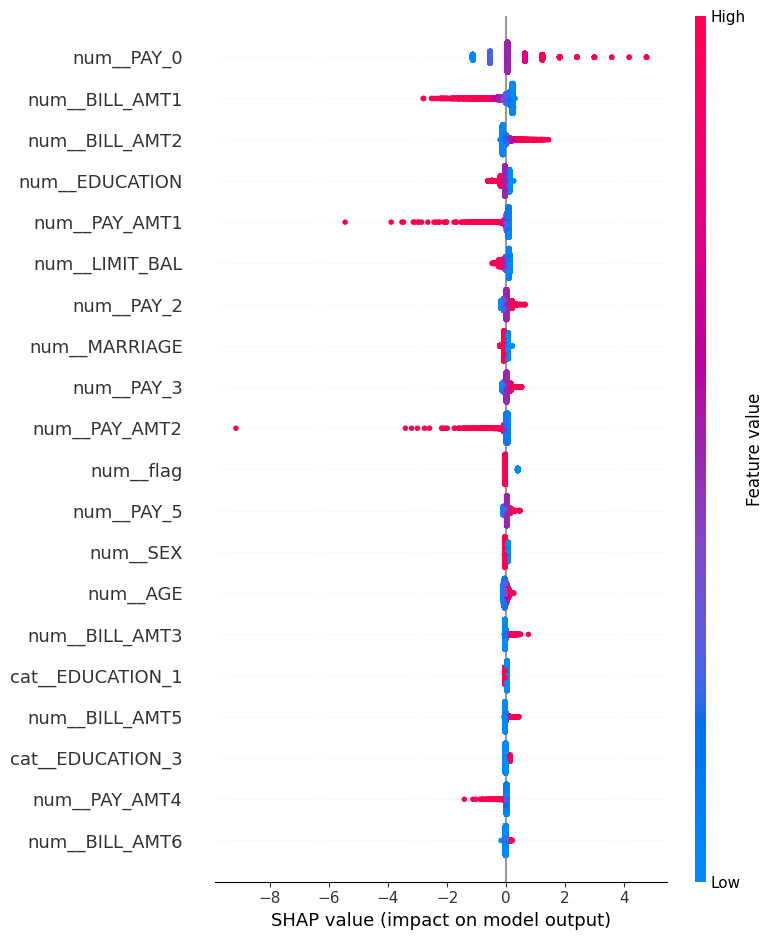

In [74]:
shap.summary_plot(shap_values.values, X_test_transformed_dense, feature_names=feature_names)

## Bar plot

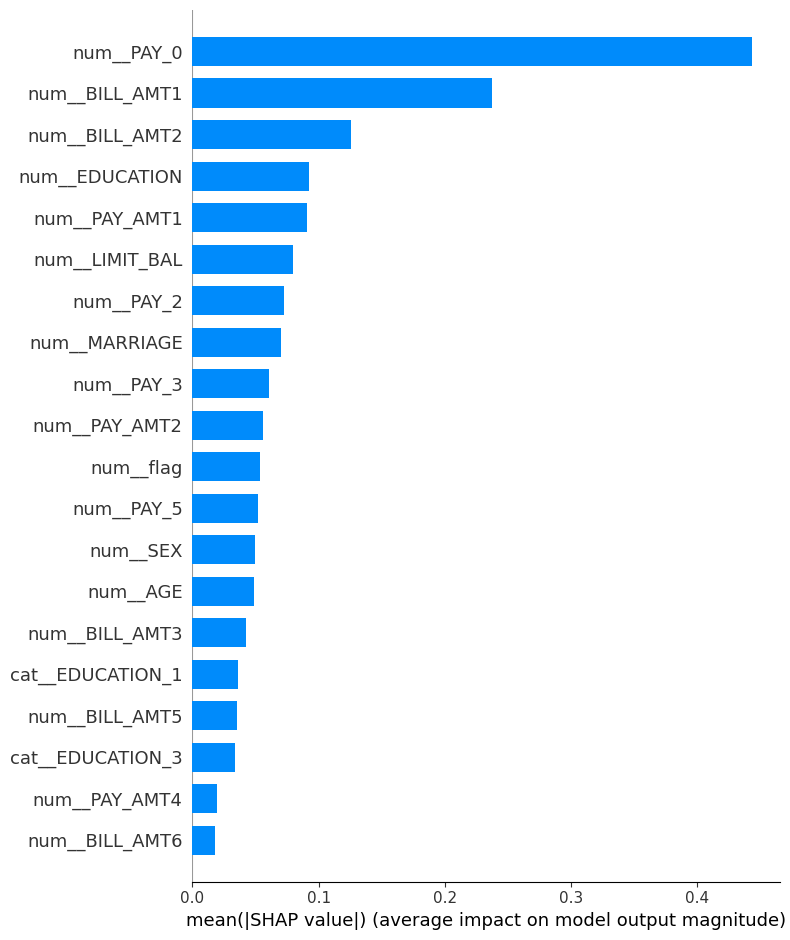

In [75]:
shap.summary_plot(shap_values.values, X_test_transformed_dense, feature_names=feature_names, plot_type="bar")

## Local explanation

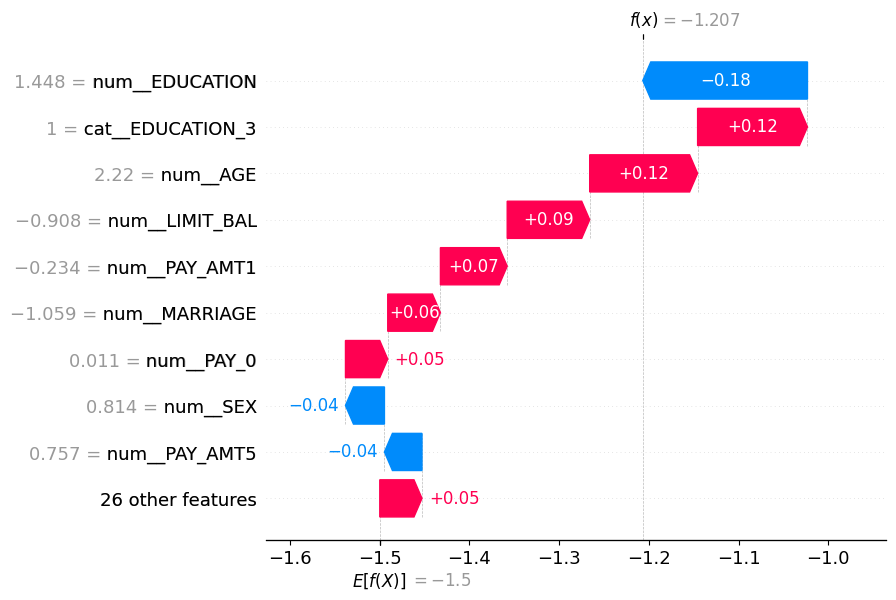

In [76]:
row_idx = 0
shap.plots.waterfall(shap_values[row_idx])

# **5. Jugar con otros modelos**

En esta sección vamos a probar modelos distintos a la regresión logística para comparar desempeño y entender mejor el trade-off entre interpretabilidad, capacidad predictiva y complejidad.

## **5.1 Modelos a probar**

### **Random Forest**
Random Forest combina muchos árboles de decisión entrenados sobre muestras distintas de los datos. Luego promedia sus predicciones. Suele capturar relaciones no lineales y es bastante robusto.

**Parámetros más importantes:**
- `n_estimators`: número de árboles. Más árboles suele mejorar estabilidad, pero aumenta tiempo de entrenamiento.
- `max_depth`: profundidad máxima de cada árbol. Profundidades muy altas pueden sobreajustar.
- `min_samples_split`: mínimo de observaciones para dividir un nodo. Ayuda a controlar complejidad.
- `min_samples_leaf`: mínimo de observaciones por hoja. Hace al árbol más estable.
- `max_features`: cuántas variables revisar en cada split. Introduce diversidad entre árboles.
- `class_weight`: útil cuando la variable objetivo está desbalanceada.

### **XGBoost**
XGBoost construye árboles de forma secuencial: cada árbol nuevo intenta corregir los errores del anterior. Suele ser uno de los modelos tabulares con mejor desempeño predictivo.

**Parámetros más importantes:**
- `n_estimators`: número de árboles del boosting.
- `learning_rate`: qué tan fuerte aporta cada árbol. Menor valor suele requerir más árboles, pero generaliza mejor.
- `max_depth`: profundidad máxima de cada árbol.
- `subsample`: porcentaje de filas usadas por árbol. Ayuda a reducir overfitting.
- `colsample_bytree`: porcentaje de columnas usadas por árbol.
- `min_child_weight`: controla cuántas observaciones efectivas necesita una hoja.
- `gamma`: ganancia mínima necesaria para dividir un nodo.
- `reg_alpha` y `reg_lambda`: regularización L1 y L2 para controlar complejidad.
- `scale_pos_weight`: ajusta el entrenamiento cuando hay desbalance entre clases.

In [77]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=52)

# ratio de clases para XGBoost
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
neg_pos_ratio

np.float64(3.5207956600361663)

## **5.2 Función para evaluar modelos**

Vamos a usar la misma lógica de evaluación para todos los modelos, para que la comparación contra el primer modelo sea consistente.

In [78]:
def evaluate_model(name, fitted_model, X_eval, y_eval, cv_scores=None):
    y_pred_local = fitted_model.predict(X_eval)
    y_pred_proba_local = fitted_model.predict_proba(X_eval)[:, 1]

    results = {
        'model': name,
        'accuracy': accuracy_score(y_eval, y_pred_local),
        'precision': precision_score(y_eval, y_pred_local, zero_division=0),
        'recall': recall_score(y_eval, y_pred_local, zero_division=0),
        'f1': f1_score(y_eval, y_pred_local, zero_division=0),
        'auc_test': roc_auc_score(y_eval, y_pred_proba_local),
    }

    if cv_scores is not None:
        results['auc_cv_mean'] = cv_scores.mean()
        results['auc_cv_std'] = cv_scores.std()

    return results, y_pred_local, y_pred_proba_local

# baseline: primer modelo (regresión logística simple)
baseline_cv_scores = cross_val_score(
    model_simple,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

baseline_results = {
    'model': 'Logistic Regression (baseline)',
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'auc_test': roc_auc_score(y_test, y_pred_proba),
    'auc_cv_mean': baseline_cv_scores.mean(),
    'auc_cv_std': baseline_cv_scores.std(),
}

pd.DataFrame([baseline_results]).round(4)

,model,accuracy,precision,recall,f1,auc_test,auc_cv_mean,auc_cv_std
0,Logistic Regression (baseline),0.8123,0.7427,0.2315,0.3529,0.7304,0.7228,0.0125


## **5.3 Random Forest**

Primero entrenamos un Random Forest con hiperparámetros razonables para tener una primera referencia antes de optimizar.

In [79]:
rf_model = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        class_weight='balanced',
        random_state=52,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

rf_results, y_pred_rf, y_pred_proba_rf = evaluate_model(
    'Random Forest', rf_model, X_test, y_test, rf_cv_scores
)

pd.DataFrame([rf_results]).round(4)

,model,accuracy,precision,recall,f1,auc_test,auc_cv_mean,auc_cv_std
0,Random Forest,0.7809,0.5041,0.5889,0.5432,0.7868,0.7775,0.0079


## **5.4 XGBoost**

Ahora probamos XGBoost. Este modelo suele capturar mejor relaciones complejas, pero también requiere más cuidado al ajustar hiperparámetros.

In [80]:
xgb_model = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        gamma=0.0,
        scale_pos_weight=neg_pos_ratio,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=52
    ))
])

xgb_model.fit(X_train, y_train)

xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

xgb_results, y_pred_xgb, y_pred_proba_xgb = evaluate_model(
    'XGBoost', xgb_model, X_test, y_test, xgb_cv_scores
)

pd.DataFrame([xgb_results]).round(4)

,model,accuracy,precision,recall,f1,auc_test,auc_cv_mean,auc_cv_std
0,XGBoost,0.7689,0.4829,0.6281,0.546,0.789,0.7799,0.008


## **5.5 Comparación contra el primer modelo**

Acá consolidamos la comparación entre la regresión logística inicial y los dos modelos nuevos.

La idea al explicarlo es:
- si sube el **AUC**, el modelo ordena mejor el riesgo;
- si sube el **recall**, detecta más clientes malos;
- si sube la **precision**, se equivoca menos al marcar malos;
- si mejora el **F1**, hay mejor balance entre precision y recall;
- el **AUC CV mean** ayuda a ver estabilidad en validación cruzada.

In [81]:
comparison_df = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results
]).round(4)

comparison_df.sort_values('auc_test', ascending=False)

,model,accuracy,precision,recall,f1,auc_test,auc_cv_mean,auc_cv_std
2,XGBoost,0.7689,0.4829,0.6281,0.5460,0.7890,0.7799,0.0080
1,Random Forest,0.7809,0.5041,0.5889,0.5432,0.7868,0.7775,0.0079
0,Logistic Regression (baseline),0.8123,0.7427,0.2315,0.3529,0.7304,0.7228,0.0125


## **6. Optimización con Optuna**

Ahora usamos **Optuna** para buscar mejores hiperparámetros. Optuna prueba combinaciones de parámetros de forma inteligente y busca maximizar una métrica objetivo.

En este caso vamos a optimizar por **f1 en validación cruzada**, porque es una métrica muy útil en problemas de clasificación binaria y riesgo.

In [82]:
import optuna

optuna.__version__

'4.8.0'

### **6.1 Optuna para Random Forest**

In [85]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 40),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]),
        'random_state': 52,
        'n_jobs': -1
    }

    model = Pipeline(steps=[
        ('prep', preprocess_simple),
        ('clf', RandomForestClassifier(**params))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )
    return scores.mean()

study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=52))
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=False)

study_rf.best_value, study_rf.best_params

[I 2026-04-22 09:43:50,838] A new study created in memory with name: no-name-a57bc8be-ccec-4254-9e77-8f514063ffd1
[I 2026-04-22 09:43:56,626] Trial 0 finished with value: 0.5378833688937232 and parameters: {'n_estimators': 521, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 13, 'max_features': 'log2', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.5378833688937232.
[I 2026-04-22 09:44:57,337] Trial 1 finished with value: 0.47648370138973445 and parameters: {'n_estimators': 437, 'max_depth': 12, 'min_samples_split': 31, 'min_samples_leaf': 9, 'max_features': None, 'class_weight': None}. Best is trial 0 with value: 0.5378833688937232.
[I 2026-04-22 09:45:00,659] Trial 2 finished with value: 0.5406625190294327 and parameters: {'n_estimators': 321, 'max_depth': 4, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.5406625190294327.
[I 2026-04-22 09:45:09,350] Trial 3 finished

(0.5492419456108537,
 {'n_estimators': 380,
  'max_depth': 13,
  'min_samples_split': 19,
  'min_samples_leaf': 15,
  'max_features': 'log2',
  'class_weight': 'balanced_subsample'})

In [86]:
rf_best_model = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', RandomForestClassifier(**study_rf.best_params, random_state=52, n_jobs=-1))
])

rf_best_model.fit(X_train, y_train)

rf_best_cv_scores = cross_val_score(
    rf_best_model,
    X_train,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

rf_best_results, y_pred_rf_best, y_pred_proba_rf_best = evaluate_model(
    'Random Forest (Optuna)', rf_best_model, X_test, y_test, rf_best_cv_scores
)

pd.DataFrame([rf_best_results]).round(4)

,model,accuracy,precision,recall,f1,auc_test,auc_cv_mean,auc_cv_std
0,Random Forest (Optuna),0.7867,0.5158,0.5799,0.546,0.7884,0.5492,0.0091


### **6.2 Optuna para XGBoost**

In [87]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', max(1.0, neg_pos_ratio * 0.7), neg_pos_ratio * 1.3),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 52
    }

    model = Pipeline(steps=[
        ('prep', preprocess_simple),
        ('clf', XGBClassifier(**params))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=52))
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=False)

study_xgb.best_value, study_xgb.best_params

[I 2026-04-22 09:48:54,137] A new study created in memory with name: no-name-2dd67fc1-ef8f-4213-a7e2-e06df8c199a7
[I 2026-04-22 09:48:55,133] Trial 0 finished with value: 0.5398499672975818 and parameters: {'n_estimators': 521, 'learning_rate': 0.01081384841412151, 'max_depth': 3, 'min_child_weight': 7, 'subsample': 0.6393137861347596, 'colsample_bytree': 0.8480525239507435, 'gamma': 0.2694510979922188, 'reg_alpha': 6.357264616846159, 'reg_lambda': 7.982646012615982, 'scale_pos_weight': 3.5654273436651787}. Best is trial 0 with value: 0.5398499672975818.
[I 2026-04-22 09:48:55,944] Trial 1 finished with value: 0.5251769377846192 and parameters: {'n_estimators': 437, 'learning_rate': 0.0988488745726917, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.907522122529497, 'colsample_bytree': 0.7692807001648126, 'gamma': 4.630517857634158, 'reg_alpha': 0.2568221186524933, 'reg_lambda': 0.006954692885826744, 'scale_pos_weight': 4.278984616678416}. Best is trial 0 with value: 0.5398499672

(0.5490628428739501,
 {'n_estimators': 590,
  'learning_rate': 0.017638448130901294,
  'max_depth': 3,
  'min_child_weight': 6,
  'subsample': 0.8263203064714751,
  'colsample_bytree': 0.8989808040767723,
  'gamma': 1.17905139944559,
  'reg_alpha': 0.8012988580256893,
  'reg_lambda': 0.00013103194530531394,
  'scale_pos_weight': 3.1135864840648337})

In [88]:
xgb_best_params = study_xgb.best_params.copy()
xgb_best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 52
})

xgb_best_model = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', XGBClassifier(**xgb_best_params))
])

xgb_best_model.fit(X_train, y_train)

xgb_best_cv_scores = cross_val_score(
    xgb_best_model,
    X_train,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

xgb_best_results, y_pred_xgb_best, y_pred_proba_xgb_best = evaluate_model(
    'XGBoost (Optuna)', xgb_best_model, X_test, y_test, xgb_best_cv_scores
)

pd.DataFrame([xgb_best_results]).round(4)

,model,accuracy,precision,recall,f1,auc_test,auc_cv_mean,auc_cv_std
0,XGBoost (Optuna),0.7847,0.5112,0.6028,0.5533,0.7916,0.5491,0.0094


## **6.3 Comparación final**

En esta tabla vemos el baseline, los modelos sin optimizar y los modelos optimizados con Optuna. Así ya puedes explicar no solo que probaste varios algoritmos, sino también que hiciste un proceso formal de búsqueda de hiperparámetros.

In [90]:
final_comparison_df = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results,
    rf_best_results,
    xgb_best_results
]).round(4)

final_comparison_df.sort_values('f1', ascending=False)

,model,accuracy,precision,recall,f1,auc_test,auc_cv_mean,auc_cv_std
4,XGBoost (Optuna),0.7847,0.5112,0.6028,0.5533,0.7916,0.5491,0.0094
2,XGBoost,0.7689,0.4829,0.6281,0.5460,0.7890,0.7799,0.0080
3,Random Forest (Optuna),0.7867,0.5158,0.5799,0.5460,0.7884,0.5492,0.0091
1,Random Forest,0.7809,0.5041,0.5889,0.5432,0.7868,0.7775,0.0079
0,Logistic Regression (baseline),0.8123,0.7427,0.2315,0.3529,0.7304,0.7228,0.0125


In [92]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1'])
cm_df

,Pred 0,Pred 1
Real 0,5708,133
Real 1,1275,384


In [91]:
cm = confusion_matrix(y_test, y_pred_xgb_best)
cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1'])
cm_df

,Pred 0,Pred 1
Real 0,4885,956
Real 1,659,1000


In [93]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.98      0.89      5841
           1       0.74      0.23      0.35      1659

    accuracy                           0.81      7500
   macro avg       0.78      0.60      0.62      7500
weighted avg       0.80      0.81      0.77      7500



In [94]:
print(classification_report(y_test, y_pred_xgb_best))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      5841
           1       0.51      0.60      0.55      1659

    accuracy                           0.78      7500
   macro avg       0.70      0.72      0.71      7500
weighted avg       0.80      0.78      0.79      7500



## **Shap values**

In [95]:
xgb_best_model

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string w

In [97]:
import shap

# Transform data using the fitted preprocessor
X_train_transformed = xgb_best_model.named_steps["prep"].transform(X_train)
X_test_transformed = xgb_best_model.named_steps["prep"].transform(X_test)

# Get transformed feature names
feature_names = xgb_best_model.named_steps["prep"].get_feature_names_out()

# Convert to dense if needed
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed_dense = X_train_transformed.toarray()
else:
    X_train_transformed_dense = X_train_transformed

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed_dense = X_test_transformed.toarray()
else:
    X_test_transformed_dense = X_test_transformed

# Extract fitted XGBoost model
xgb_clf = xgb_best_model.named_steps["clf"]

# Build SHAP explainer for tree-based model
explainer = shap.TreeExplainer(xgb_clf)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_transformed_dense)

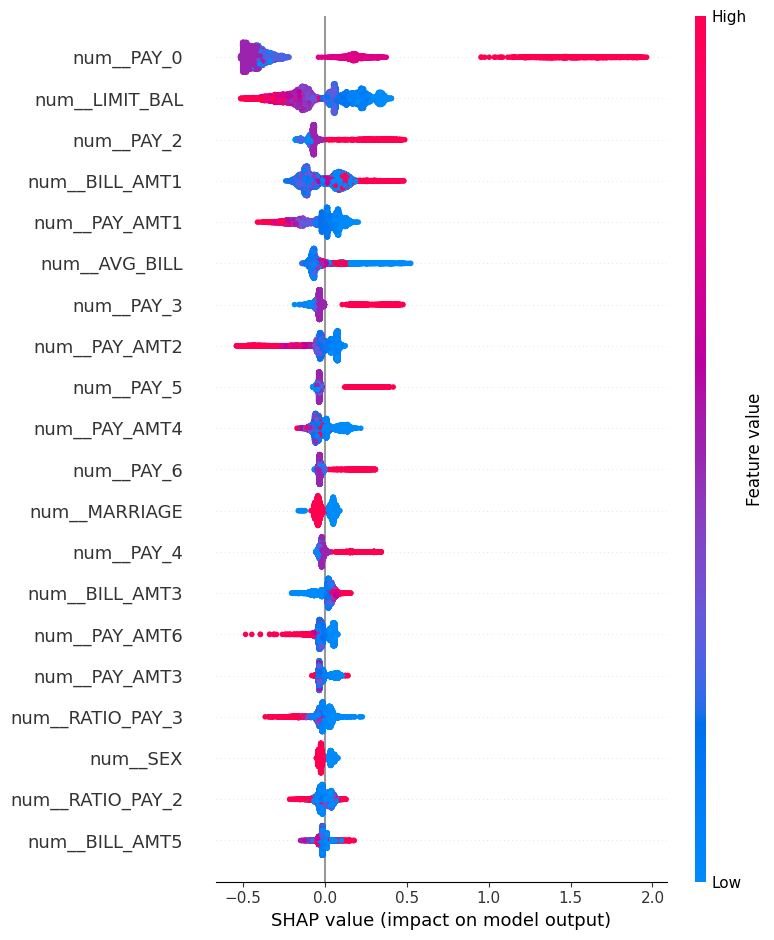

In [100]:
shap.summary_plot(shap_values, X_test_transformed_dense, feature_names=feature_names)

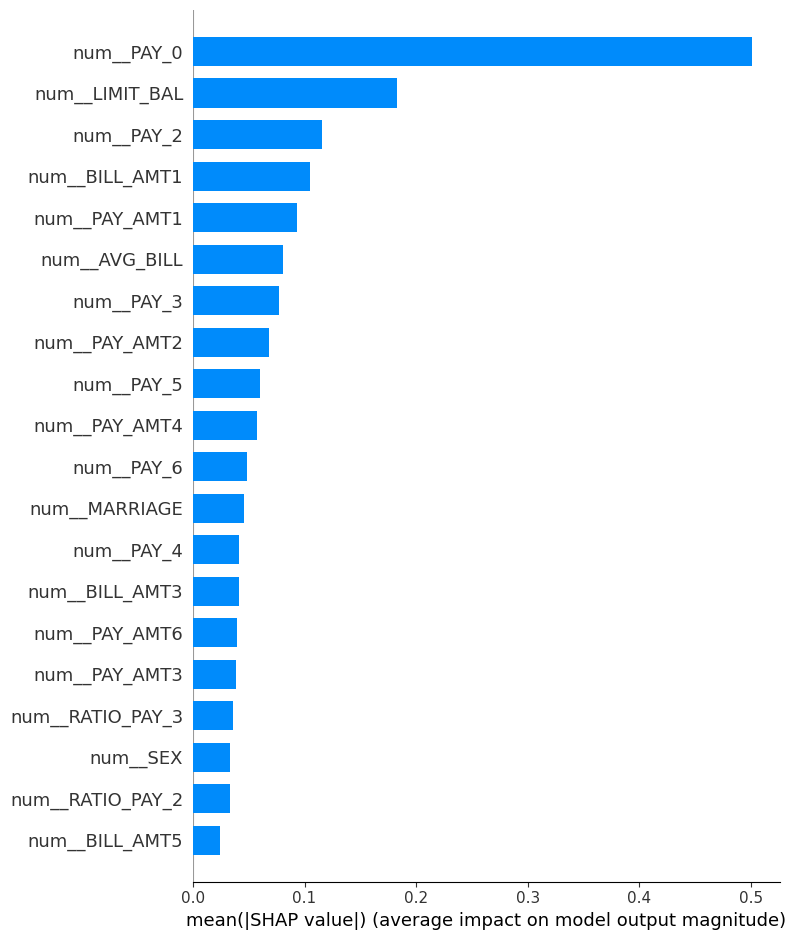

In [101]:
shap.summary_plot(shap_values, X_test_transformed_dense, feature_names=feature_names, plot_type="bar")

In [111]:
explainer = shap.TreeExplainer(xgb_clf, feature_names=feature_names,)
exp = explainer(X_test_transformed_dense) # <-- here
print(type(exp))

#shap_values = explainer.shap_values(X_test_transformed_dense)

<class 'shap._explanation.Explanation'>


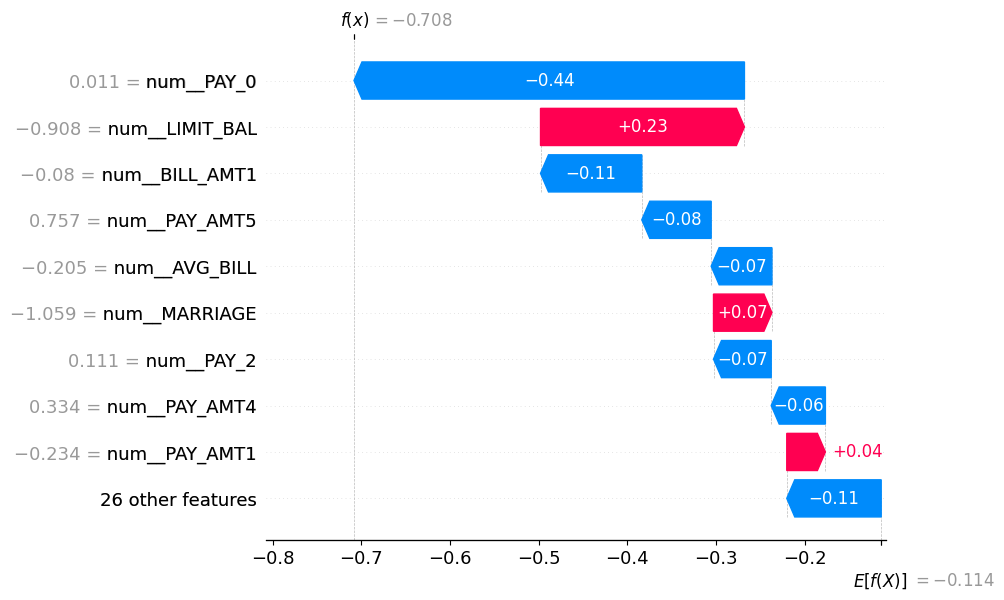

In [112]:
shap.plots.waterfall(exp[0])